In [66]:
import torch
from pathlib import Path
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from IPython.display import clear_output


In [67]:
TRAINING_DATA_DIR = Path("../data/brain_mri/Training/")
TESTING_DATA_DIR = Path("../data/brain_mri/Testing/")

In [68]:
class cnn(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1  3x224x224 -> 16x224x224 -> 16x112x112
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # Block 2  16x112x112 -> 32x112x112 -> 32x56x56
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # Block 3  32x56x56 -> 64x56x56 -> 64x28x28
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
# test cnn network
images = torch.randn(1, 3, 224, 224)
model = cnn(num_classes=4)
output = model(images)

print(output.shape)

torch.Size([1, 4])


In [70]:
transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ]
)

training_dataset = datasets.ImageFolder(
    root=TRAINING_DATA_DIR,
    transform=transform,
)

testing_dataset = datasets.ImageFolder(
    root=TESTING_DATA_DIR,
    transform=transform,
)

batch_size = 64
train_dataloader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(testing_dataset, batch_size=batch_size, shuffle=False)

In [71]:
def train(dataloader, model, loss_fn, optimizer, device):
    model.train()

    size = len(dataloader.dataset)
    total_loss = 0
    correct = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size = images.shape[0]
        total_loss += loss.item() * batch_size
        correct += (outputs.argmax(1) == labels).type(torch.float).sum().item()

    avg_loss = total_loss / size
    accuracy = correct / size

    return avg_loss, accuracy


In [72]:
def test(dataloader, model, loss_fn, device):
    model.eval()

    size = len(dataloader.dataset)
    total_loss = 0
    correct = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item() * images.shape[0]
            correct += (outputs.argmax(1) == labels).type(torch.float).sum().item()

    avg_loss = total_loss / size
    accuracy = correct / size

    return avg_loss, accuracy


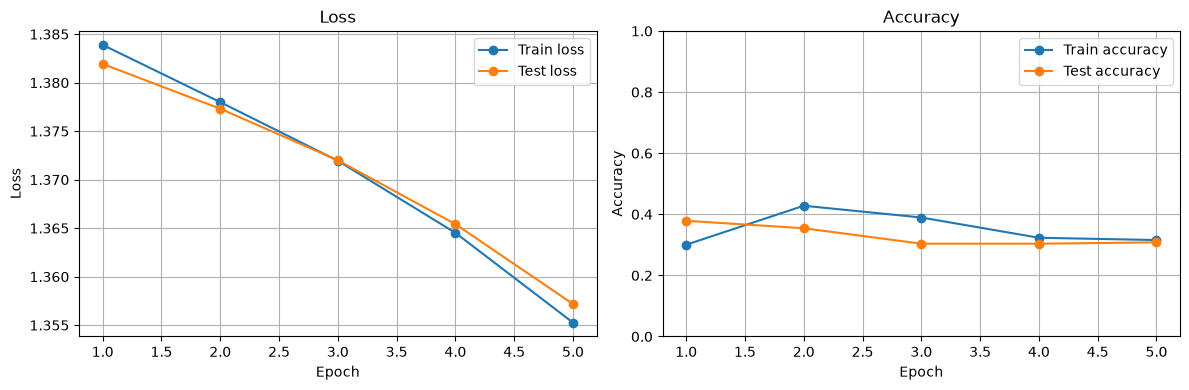

Epoch 5/5
Train loss: 1.3553, Train accuracy: 31.6%
Test loss: 1.3572, Test accuracy: 30.8%


In [73]:
epochs = 5

# Initialize model, loss and optimizer in the controlling scope and pass them into functions
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = cnn(num_classes=len(training_dataset.classes)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-3)

train_losses = []
train_accs = []
test_losses = []
test_accs = []

for epoch in range(epochs):
    train_loss, train_acc = train(train_dataloader, model, loss_fn, optimizer, device)
    test_loss, test_acc = test(test_dataloader, model, loss_fn, device)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    clear_output(wait=True)

    epoch_range = range(1, epoch + 2)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epoch_range, train_losses, marker="o", label="Train loss")
    axes[0].plot(epoch_range, test_losses, marker="o", label="Test loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epoch_range, train_accs, marker="o", label="Train accuracy")
    axes[1].plot(epoch_range, test_accs, marker="o", label="Test accuracy")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0, 1)
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train loss: {train_loss:.4f}, Train accuracy: {100*train_acc:.1f}%")
    print(f"Test loss: {test_loss:.4f}, Test accuracy: {100*test_acc:.1f}%")
